 **Background**</a>

Risk management includes all the steps of the “Checklist” that provide insight into the ex-ante risk profile of an investment portfolio. More specifically, it models the <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=perf-attri-linear" class="@formulas #perf-attri-linear">ex-ante distribution of portfolio performance</a>, quantifies potential downsides through formal <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=fGsaf" class="@formulas #fGsaf">risk measures</a>, and employs attribution to decompose both <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=subvkabsfads-copy-1" class="@formulas #subvkabsfads-copy-1">performance</a> and <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=riskattrsatisf-copy-2-bis" class="@formulas #riskattrsatisf-copy-2-bis">risk</a> into underlying risk factors. This process relies on the quantitative outputs derived from the preceding financial engineering steps.

<a><i class="fa fa-folder" style="color:#61A5C2; font-size:20px;"></i>  **Data**</a>

- Joint payoff distribution of five stocks from US tech companies.
    - Tickers: "MSFT", "AAPL", "NVDA", "AMZN", "GOOGL".
    - Scenario probability distribution with equal probabilities.
    - 1,000 scenarios.
- Current time is set equal to 02/01/2023.
- Investment horizon: one business week from current time.

</p></div></div>

<h1 style="font-weight: bold; font-size:14px; line-height:1.5em;"><i class="fa fa-gear" style="color:#61A5C2; font-size:20px;"></i> Prepare environment</h1>

In [ ]:
from pandas import read_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Math
from scipy.stats import norm as normal
from sklearn.linear_model import Lasso


<h1 style="font-weight: bold; font-size:14px; line-height:1.5em;"><i class="fa fa-download" style="color:#61A5C2; font-size:20px;"></i> Import data</h1>

In [ ]:
db_PP_market_payoffs = read_csv('~/Databases/temporary-databases/db_PP_market_payoffs.csv', index_col=0)
# stock payoff scenarios
stock_payoffs = db_PP_market_payoffs.iloc[:, :5]
display(stock_payoffs.head(5))
pi = stock_payoffs.values  # payoff scenarios
stocks = stock_payoffs.columns  # stock tickers
j_bar = pi.shape[0]  # number of scenarios
# payoff probabilities
p_scenario = db_PP_market_payoffs.iloc[:, -1].values.squeeze()

# stock current values
db_PP_market_values = read_csv('~/Databases/temporary-databases/db_PP_market_values.csv', index_col=0)
v = db_PP_market_values.values.squeeze()

,MSFT,AAPL,NVDA,AMZN,GOOGL
0,235.744605,144.147981,20.456671,101.743705,99.586750
1,230.349675,136.723015,16.316816,95.967237,95.559243
2,243.359352,142.389031,20.677245,104.544996,97.045075
3,242.582218,142.012337,20.644431,104.331588,98.236208
4,238.859570,141.762851,20.479000,104.977591,97.490824


<div style="border-left: 4px solid #61A5C2; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #dfedf2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#61A5C2; font-size:20px;"></i> Task 1:  Value aggregation</h1>
  </div>
  <div style="padding: 1em;">
  <p>

Consider the <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=asiufauifsaad" class="@formulas #asiufauifsaad">buy-and-hold portfolio</a> composed of the following holdings in the 5 technology stocks
$$\boldsymbol{h}=(1000,\,2000,\,10000,\,2000,\,2000)'\text{.}$$

- Compute the <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=poiajddaa-copy-3" class="@formulas #poiajddaa-copy-3">current value</a> of the portfolio. Justify your method and any adjustments you make to the value.
- Compute the <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=GenWeights" class="@formulas #GenWeights">portfolio weights</a>, using appropriate denominators.
</p></div></div>

<IPython.core.display.Math object>

,$\boldsymbol{w}_{\boldsymbol{h}}$
Instrument,
MSFT,0.215028
AAPL,0.252921
NVDA,0.173791
AMZN,0.183672
GOOGL,0.174588


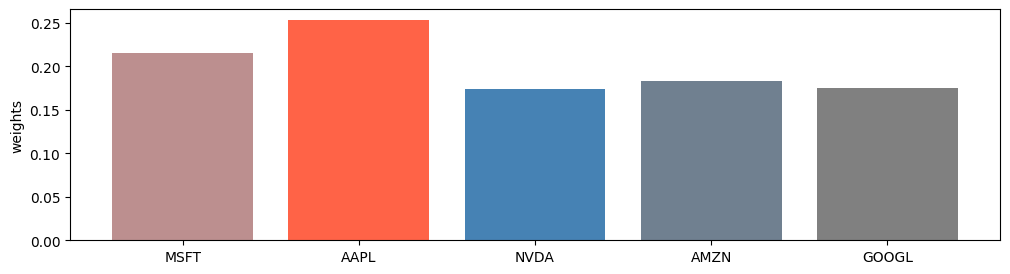

In [ ]:
# Value aggregation
h = np.array([1000,2000,10000, 2000, 2000])
v_p = h @ v
display(Math(r"v^{\boldsymbol{h}} = \$" + "{:,.0f}".format(round(v_p))))
w_h = h * v/v_p
weight = pd.DataFrame({'Instrument': stocks, r"$\boldsymbol{w}_{\boldsymbol{h}}$": w_h}).set_index('Instrument')
display(weight)
fig, axes = plt.subplots(figsize = (12,3))
plt.bar(stocks, w_h, color = ['rosybrown', 'tomato','steelblue', 'slategray', 'grey'] )
plt.ylabel('weights')
plt.show()


</div>
Under the buy-and-hold assumption, the current value of the portfolio was computed as the sum of the market values of each stock position. Using the specified holdings of 1,000 shares of MSFT, 2,000 shares of AAPL, 10,000 shares of NVDA, 2,000 shares of AMZN, and 2,000 shares of GOOGL, the current portfolio value was calculated as
$
V^{\mathbf{h}}=$1,122,981.

Portfolio weights were then obtained using the market value of each position divided by the total portfolio value. The portfolio is not equally weighted. AAPL represents the largest exposure at approximately 25.3% of the portfolio value, followed by MSFT at 21.5%. Although the portfolio contains 10,000 shares of NVDA, its portfolio weight is lower because portfolio weights depend on the market value of each position rather than the number of shares held.

<div style="border-left: 4px solid #61A5C2; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #dfedf2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#61A5C2; font-size:20px;"></i> Task 2: Performance aggregation</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Compute the joint <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=ret-scen" class="@formulas #ret-scen">return scenarios</a> for the instruments at the investment horizon.
- Obtain the distribution of the <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=PtfLRet" class="@formulas #PtfLRet">ex-ante portfolio return</a> and plot the distribution.
  
</p></div></div>

Mean    0.003675
Std     0.048019
Min    -0.174713
Max     0.178013
dtype: float64

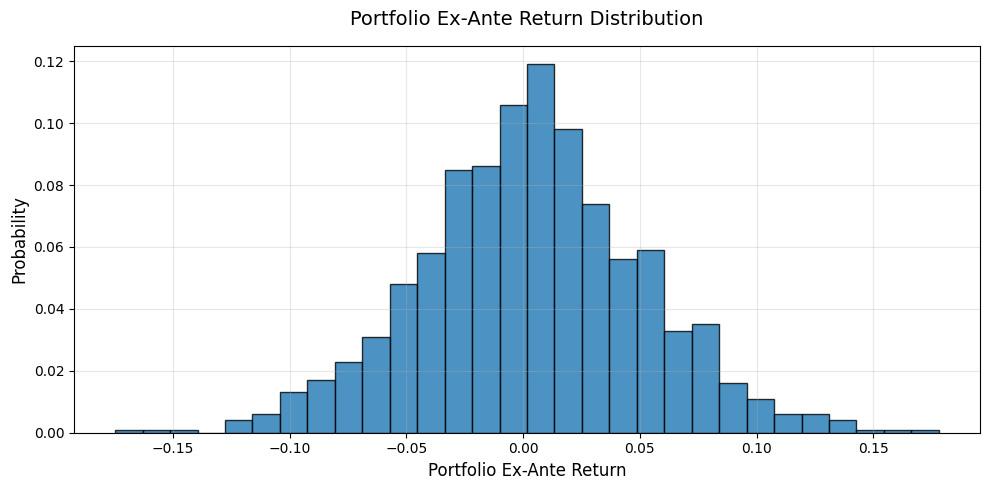

In [ ]:
r = (pi - v)/v  # instrument returns

r_w = w_h@r.T  # portfolio ex-ante return
display(pd.Series({"Mean": np.sum(p_scenario*r_w),"Std": np.sqrt(np.sum(p_scenario*(r_w-np.sum(p_scenario*r_w))**2)),"Min": r_w.min(),"Max": r_w.max()}))

########################################### plot ###########################################
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(r_w,bins=30,weights=p_scenario,edgecolor="black", alpha=0.8)

ax.set_xlabel("Portfolio Ex-Ante Return", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Portfolio Ex-Ante Return Distribution",fontsize=14,pad=15)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

</div>

The Performance aggregation step consists of the computation of the ex-ante performance associated with a static allocation h mentioned in task one.The ex-ante performance is the linear return of the portfolio, which is the weighted average of the returns of the stocks. Joint return scenarios for each stock were computed from the payoff scenarios over the one-week investment horizon.The portfolio exhibits a positive expected one-week return of approximately 0.37%, indicating a favourable average outcome across scenarios. However, the relatively large standard deviation of 4.80% suggests considerable uncertainty around this expectation. The scenario analysis also reveals substantial downside and upside potential, with returns ranging from a loss of 17.47% to a gain of 17.80% over the investment horizon. This wide range reflects the inherent volatility of a portfolio concentrated in large U.S. technology stocks.


<div style="border-left: 4px solid #61A5C2; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #dfedf2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#61A5C2; font-size:20px;"></i> Task 3: Ex-ante evaluation</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Compute <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=eval-loss" class="@formulas #eval-loss">loss distribution</a> and plot it.
- Compute appropriate <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=fGsaf" class="@formulas #fGsaf">risk measures</a>.
- Discuss the risk measures you chose to compute. Interpret the risk values with reference to the loss distribution. Are there any causes for concern?

</p></div></div>

Expected Loss


<IPython.core.display.Math object>

Loss Variance


<IPython.core.display.Math object>

Loss Standard deviation


<IPython.core.display.Math object>

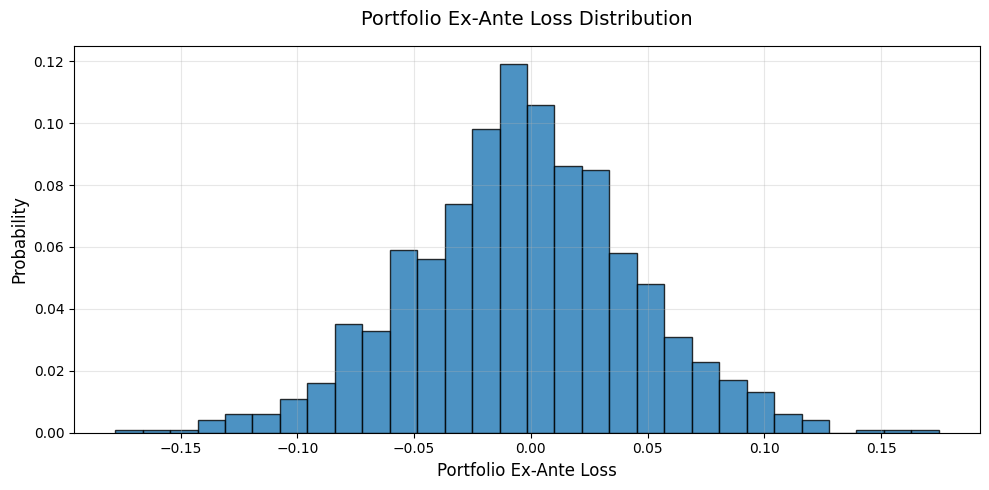

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Risk Measure
Expected Loss,-0.0037
Variance Loss,0.0023
Standard deviation Loss,0.0480
q_r,0.1055
sub_q_r,0.1263
alpha,0.9900


In [ ]:
p_scenario = p_scenario / np.sum(p_scenario)
l = -r_w  # loss scenarios
e_l = np.average(l, weights=p_scenario)
print('Expected Loss')
display(Math(r'\mathbb{E}\{L\} = ' + f'{(e_l*100).round(2)}\\%'))

v_l = np.cov(l, aweights=p_scenario, bias=True)
print('Loss Variance')
display(Math(r'\mathbb{V}\{L\} = ' + f'{((v_l)*100).round(1)}') )

std_l = np.sqrt(v_l)
print('Loss Standard deviation')
display(Math(r'\mathbb{std}\{L\} =' + f'{((std_l)*100).round(1)}'))

########################################### plot ###########################################
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(l ,bins=30,weights=p_scenario,edgecolor="black", alpha=0.8)

ax.set_xlabel("Portfolio Ex-Ante Loss", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Portfolio Ex-Ante Loss Distribution",fontsize=14,pad=15)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

alpha = 0.99  # confidence level for quantile and super-quantile
l_sort = np.argsort(l)
loss_sorted = l[l_sort]  # sorted loss scenarios
p_sort = p_scenario[l_sort]  # sorted probabilities
u_sort = np.append(0, np.cumsum(p_sort))  # cumulative sums of sorted probabilities
q_l = loss_sorted[np.logical_and(u_sort[1:] >= alpha, u_sort[:-1] < alpha)][0]  # quantile (VaR)
display(Math(r'q_{L}(0.99) = ' + f'{(q_l*100).round(4)}\\%'))

#scenario-based (nonparametric) VaR / CVaR estimation with smoothing
h = 0.06*(len(r_w)**-0.2)  # smoothing parameter
w = np.diff(normal.cdf(u_sort, alpha, h))  # weights
w = w/sum(w)  # rescaled weights
q_l_smooth = loss_sorted@w  # smooth quantile
display(Math('VaR(0.99) = ' + f'{(q_l_smooth*100).round(4)}\\%'))

w = (1/(1-alpha))*p_sort*(np.round(u_sort[1:], 5) >= round(alpha, 2))  # weights
w = w/sum(w)  # rescaled weights
sup_q_l = loss_sorted@w  # super-quantile
display(Math('CVaR(0.99) = ' + f'{(sup_q_l*100).round(2)}\\%'))

index = ['Expected Loss','Variance Loss','Standard deviation Loss','q_r','sub_q_r', 'alpha']
data = np.round([e_l, v_l, std_l, q_l, sup_q_l, alpha],4)
out = pd.DataFrame(data = data, index = index, columns = ['Risk Measure'])

out


To evaluate downside risk, the portfolio loss distribution was constructed by defining loss as the negative of the portfolio return. Several complementary risk measures were calculated to assess different aspects of the portfolio's risk profile.
The expected loss is equal to -0.37%, implying that the portfolio is expected to generate a positive return of approximately 0.37% over the one-week horizon. Although the expected outcome is favourable, this measure alone provides limited information regarding extreme losses.
The standard deviation of losses is 4.80%, indicating that realized outcomes may deviate substantially from the expected value. Given the concentration of the portfolio in technology stocks, this level of volatility is not unexpected.
To quantify tail risk, the 99% Value-at-Risk (VaR) was computed. The estimated VaR of 10.55% implies that, with 99% confidence, the portfolio is not expected to lose more than 10.55% of its value over one week, which is 0.1055×1,122,981≈118,475 dollars. Equivalently, there is a 1% probability that losses will exceed this threshold.With 99% confidence, the portfolio is not expected to lose more than approximately 118,475 dollars over the one-week horizon.
Because VaR does not provide information about the magnitude of losses beyond the threshold, the 99% Conditional Value-at-Risk (CVaR) was also evaluated. The estimated CVaR of 12.63% indicates that, 0.1263×1,122,981≈141,822 dollars, conditional on the worst 1% of scenarios occurring, the average portfolio loss is expected to be 12.63%. If the worst 1% of scenarios materialize, the expected loss increases to approximately 141,822 dollars."

The difference between CVaR and VaR suggests the presence of meaningful tail risk in the loss distribution. While the portfolio exhibits a positive expected return, the potential for double-digit losses within a one-week period should be a cause for concern, particularly for risk-averse investors. The concentration of the portfolio in a single sector—large U.S. technology companies—may amplify losses during adverse market conditions, highlighting the benefits that could arise from greater diversification.


<div style="border-left: 4px solid #61A5C2; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #dfedf2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#61A5C2; font-size:20px;"></i> Task 4: Ex-ante performance attribution</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- The risk factors available are the returns of the individual stocks. <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=subvkabsfads-copy-1" class="@formulas #subvkabsfads-copy-1">Attribute performance</a> to a set of at most 3 risk factors.
- Obtain the <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=scen-prob-z0" class="@formulas #scen-prob-z0">joint distribution of the factors</a>.

</p></div></div>

In [ ]:
z = r  # instrument returns

m_y = np.average(r_w, weights=p_scenario)  # mean performance
m_z = np.average(z, weights=p_scenario, axis=0)  # factor means
y_p = np.sqrt(p_scenario)*(r_w - m_y)  # standardized performance
z_p = np.sqrt(p_scenario).reshape(-1, 1)*(z - m_z)  # standardized factors

lam = 2e-3  # parameter for lasso regression
clf = Lasso(alpha=lam/(2.*r_w.shape[0]), fit_intercept=False)  # lasso regression
clf.fit(z_p, y_p)  # fit lasso
beta = clf.coef_  # exposures
alpha = m_y - beta@m_z  # shift
u = r_w - alpha - z@beta  # residuals

beta_coef = pd.DataFrame(data = beta, index = stock_payoffs.columns, columns = ['Beta'])
beta_coef

,Beta
MSFT,0.000000
AAPL,0.000000
NVDA,0.312298
AMZN,0.063061
GOOGL,0.012595


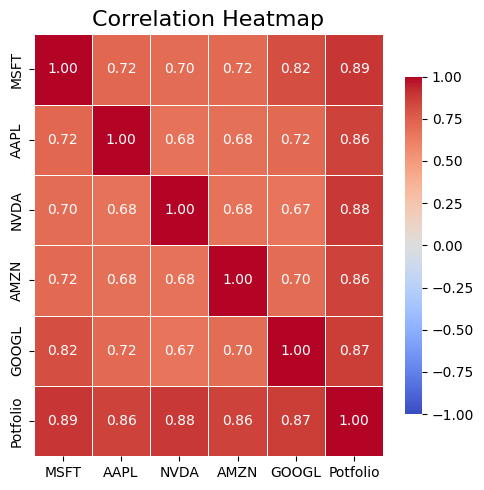

In [ ]:
z_df = pd.DataFrame(z_p, columns = stock_payoffs.columns)
z_df['Potfolio'] = r_w
plt.figure(figsize=(5, 5))
sns.heatmap(z_df.corr(), annot=True,  fmt=".2f",  cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5,  cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# selected data for relevant risk factors only
ind_relevant_risk_factors = np.where(beta != 0)[0]
beta = beta[ind_relevant_risk_factors]
rel_z = z[:, ind_relevant_risk_factors]
k_bar = beta.shape[0]  # number of relevant risk factors
f_uz = (np.c_[u, rel_z], p_scenario)  # joint distribution of residual and risk factors
z_0 = alpha + u  # map residuals to 0-th factor
beta_0 = 1  # exposure to residual
beta = np.append(beta_0, beta)  # updated exposures

rel_z = np.c_[z_0, rel_z]  # joint scenarios of risk factors


The objective of ex-ante performance attribution is to identify which stock returns best explain the variation in the portfolio return. In other words, we seek to answer the question:

> **Which stock returns explain the changes in the portfolio return?**

Using LASSO regression, we also impose a sparsity constraint and ask:

> **Can the portfolio return be explained almost as well using only a few risk factors?**

The portfolio return was treated as the dependent variable, while the individual stock returns (MSFT, AAPL, NVDA, AMZN, and GOOGL) served as candidate explanatory factors. The LASSO procedure selected NVDA, AMZN, and GOOGL as the most relevant factors, while the coefficients for MSFT and AAPL were shrunk to zero.

It is important to note that these attribution coefficients should not be interpreted as portfolio weights. Portfolio weights describe how the portfolio is invested, whereas attribution coefficients identify which factors provide the greatest explanatory power for fluctuations in portfolio performance.

Although AAPL and MSFT represent the largest portfolio weights, they do not provide substantial additional explanatory power once the selected factors are included in the model. The correlation heatmap indicates that all five technology stocks exhibit positive co-movement. However, NVDA displays the lowest correlation with the other stocks, followed by AMZN, suggesting that they contain more unique information about portfolio movements. In addition, NVDA tends to exhibit larger return fluctuations than the other stocks, allowing it to capture a significant portion of the portfolio's variation.

Therefore, the results suggest that NVDA is the dominant driver of portfolio return variability, while AMZN and GOOGL contribute additional explanatory power. After accounting for these factors, the returns of AAPL and MSFT add little incremental information to explain the cross-scenario variation in portfolio performance.

<div style="border-left: 4px solid #61A5C2; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #dfedf2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#61A5C2; font-size:20px;"></i> Task 5: Ex-ante risk attribution </h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Perform <a style="color:#193cb8" href="https://www.arpm.co/lab/redirect.php?permalink=riskattrsatisf-copy-2-bis" class="@formulas #riskattrsatisf-copy-2-bis">risk attribution</a> for one of the risk measures (excluding the expected loss) computed in **Task 3**.
- Comment on the attribution.

</p></div></div>

sd_euler =  [0.019  0.0254 0.0031 0.0006]
var_euler =  [9.1270e-04 1.2198e-03 1.4650e-04 2.6900e-05]
q_l_euler =  [0.0684 0.0266 0.0089 0.0016]
superq_l_euler =  [0.0562 0.0615 0.0092 0.0014]


,Standard deviation Contribution,Variance Contribution,VaR Contribution,CVaR Contribution
Residual,0.0190,0.0009,0.0684,0.0562
NVDA,0.0254,0.0012,0.0266,0.0615
AMZN,0.0031,0.0001,0.0089,0.0092
GOOGL,0.0006,0.0000,0.0016,0.0014
Contribution Sum,0.0480,0.0023,0.1055,0.1283
Risk Measures,0.0480,0.0023,0.1055,0.1263


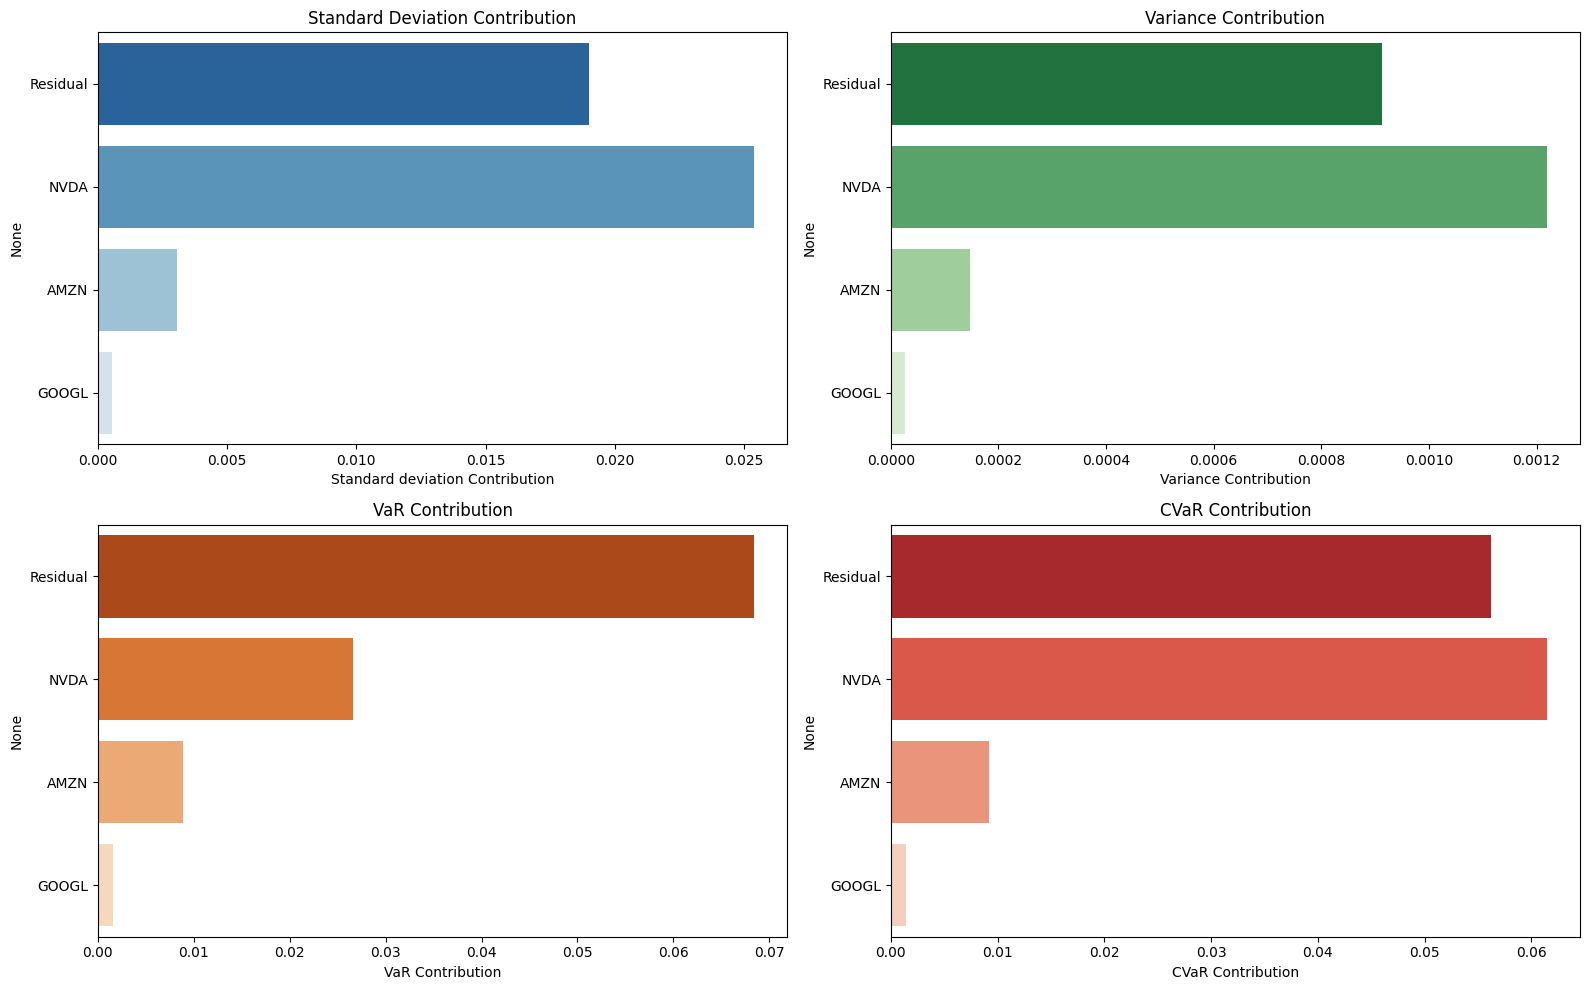

In [ ]:
# Euler decomposition of standard deviation
# covariance of the factors
mean_z = p_scenario @rel_z
sigma2_z = ((rel_z - mean_z).T * p_scenario) @ (rel_z - mean_z)

gamma = -beta
sd_euler = gamma *(sigma2_z @ gamma)/np.sqrt(gamma@sigma2_z@gamma.T)
print('sd_euler = ' , sd_euler.round(4))

# Euler decomposition of variance
var_euler = gamma*(sigma2_z@ gamma)
print('var_euler = ', var_euler.round(7))

# Euler decomposition of quantile
alpha = 0.99
j_alpha = np.min(np.where(np.cumsum(p_sort) >= alpha))
z_sort = rel_z[np.argsort(l)]
q_l_euler = (gamma * z_sort)[j_alpha]
print('q_l_euler = ', q_l_euler.round(4))

# Euler decomposition of super quantile
alpha = 0.99
j_alpha = np.min(np.where(np.cumsum(p_sort) >= alpha))
w = np.zeros((j_bar))
for j in range(j_alpha+1, j_bar):
    w[j] = 1/(1 - alpha)*p_sort[j]
w[j_alpha] = 1 - sum(w)

sup_q_contrib = gamma*(w.T@z_sort)  # factor contributions
print('superq_l_euler = ', sup_q_contrib.round(4))


result = pd.DataFrame({'Standard deviation Contribution': sd_euler,
                       'Variance Contribution': var_euler,
                       'VaR Contribution': q_l_euler,
                       'CVaR Contribution': sup_q_contrib},index = ['Residual', 'NVDA','AMZN', 'GOOGL'])
result.loc['Contribution Sum', : ] = [sum(sd_euler), sum(var_euler), sum(q_l_euler), sum(sup_q_contrib)]
result.loc['Risk Measures', : ] = [std_l, v_l, q_l, sup_q_l]
def highlight_rows(row):
    if row.name == 'Contribution Sum':
        return ['font-weight: bold; background-color: #D9EAD3'] * len(row)
    elif row.name == 'Risk Measures':
        return ['font-weight: bold; background-color: #FCE5CD'] * len(row)
    return [''] * len(row)

display(result.style.format('{:.4f}').apply(highlight_rows, axis=1))
contrib = result.iloc[:4]  # first 4 rows
contrib = result.iloc[:4]  # Residual, NVDA, AMZN, GOOGL

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=contrib,y=contrib.index,x='Standard deviation Contribution',hue=contrib.index,palette='Blues_r',legend=False,ax=axes[0,0])
axes[0,0].set_title('Standard Deviation Contribution')
sns.barplot(data=contrib,y=contrib.index,x='Variance Contribution',hue=contrib.index,palette='Greens_r',legend=False,ax=axes[0,1])
axes[0,1].set_title('Variance Contribution')
sns.barplot(data=contrib,y=contrib.index,x='VaR Contribution',hue=contrib.index,palette='Oranges_r',legend=False,ax=axes[1,0])
axes[1,0].set_title('VaR Contribution')
sns.barplot(data=contrib,y=contrib.index,x='CVaR Contribution',hue=contrib.index,palette='Reds_r',legend=False,ax=axes[1,1])
axes[1,1].set_title('CVaR Contribution')
plt.tight_layout()
plt.show()

NVDA and residual factor dominate both volatility and tail risk, indicating that the portfolio behaves as a concentrated exposure to a high-volatility tech driver rather than a simple weighted basket.The Euler decomposition shows that the residual component contributes approximately 39% of portfolio variance but nearly 65% of VaR and 45% of CVaR. This indicates that the residual factor plays a disproportionately large role in generating extreme losses. The result suggests that the residual distribution may exhibit heavy tails or that important systematic risk factors remain unexplained by the current factor specification.